In [20]:
# Import necessary libraries
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix

In [2]:
# Import Categorical Naive Bayes from naive_bayes module
from sklearn.naive_bayes import CategoricalNB

In [3]:
FILE_PATH = Path.cwd().parent / "datasets" / "mushrooms.csv"

In [4]:
df = pd.read_csv(FILE_PATH) # Import the dataset

In [5]:
df.head(5) # Inspect the data

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [7]:
df.info() # Look for dtypes and null values.
# A complete clean dataset indead

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [8]:
df.isna().sum().sum() # Rechecking null values 

np.int64(0)

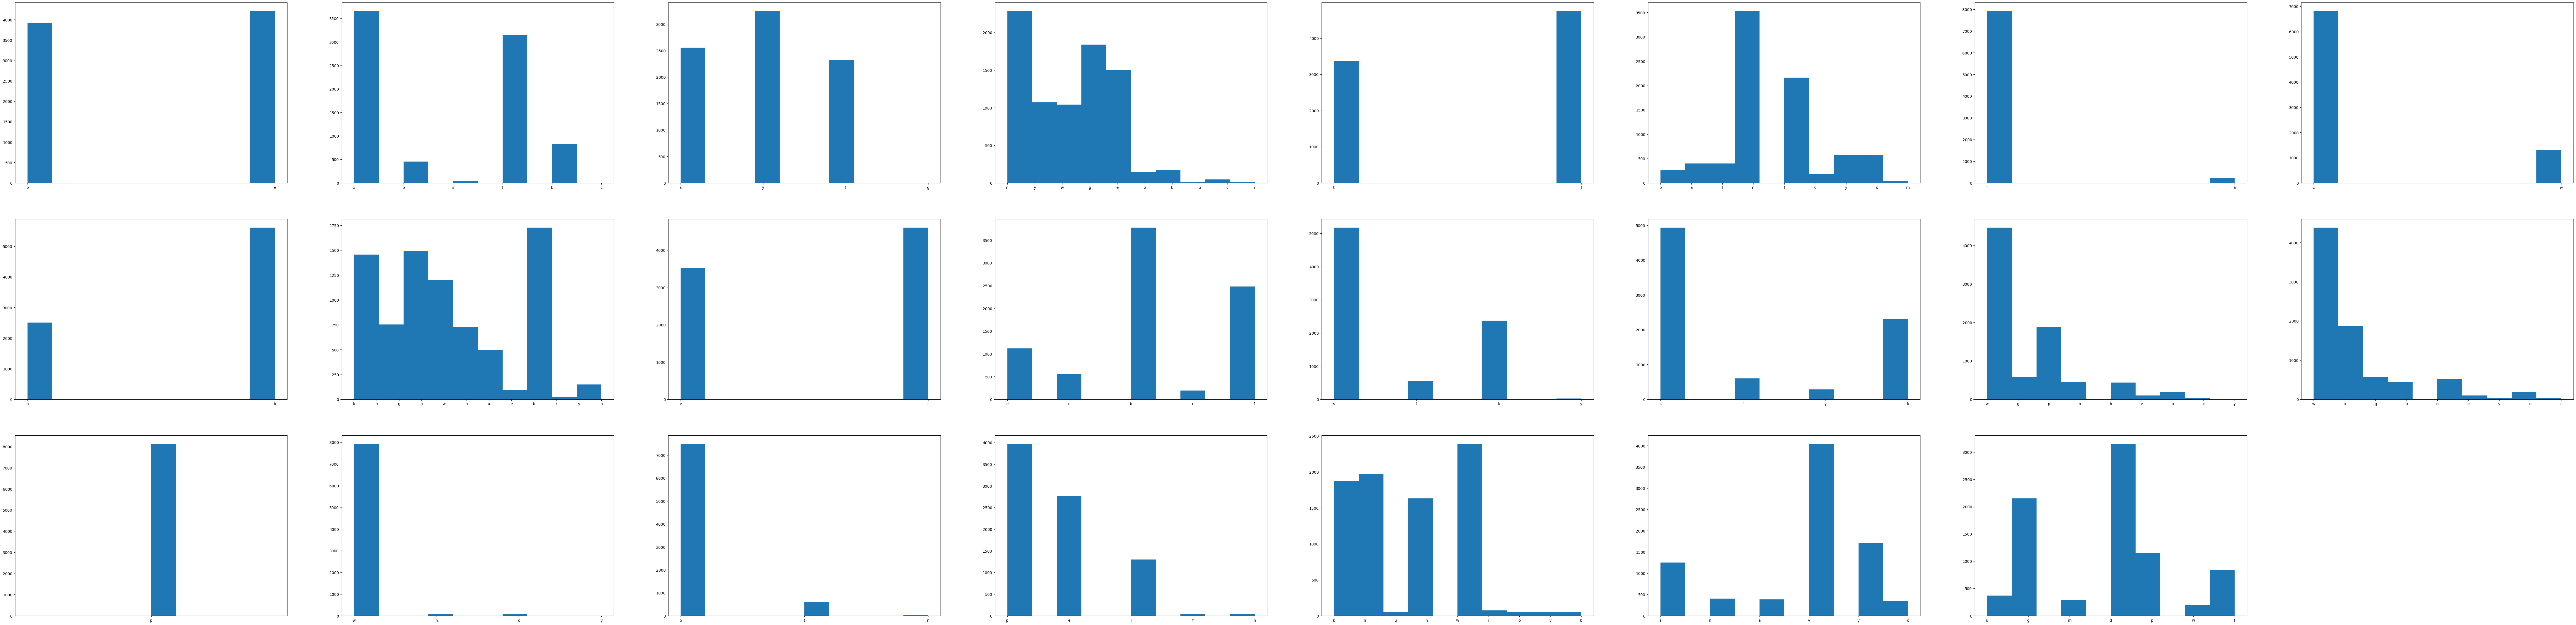

In [13]:
# Plotting the histplot for the columns and understanding them.
min = int(np.round(len(df.columns)/3))
max = int(np.ceil(len(df.columns)/3))

plt.figure(figsize=(max*15,min*10))
for x in range((len(df.columns))):
    plt.subplot(min,max,x+1)
    plt.hist(
                x = df.iloc[:,x]
    )
plt.show()

In [14]:
# Split the dataset into variables and labels.
X = df.drop(columns=['class'])
y = df['class']

In [15]:
# Now we will use different encoding methods for differnt columns accordingly.
from sklearn.preprocessing import OrdinalEncoder,LabelEncoder

In [16]:
# As all the X columns are ordinal ('With No order') we will use the OrdinalEncoder for it .
ord_endcoder = OrdinalEncoder()
encoded_cols = ord_endcoder.fit_transform(X)

In [17]:
# As all the y columns are labels we are advised to use the LabelEncoder
lab_endcoder = LabelEncoder()
labelled_cols = lab_endcoder.fit_transform(y)

In [29]:
# Split the dataset now so that we can have a testing set ( a random sample )
X_train , X_test , y_train , y_test = train_test_split(encoded_cols,labelled_cols,test_size=0.2,random_state=42)

In [30]:
# Now Instantiating the NaiveBayesClassifer and fitting the endoded columns
nvb_categorical_clf = CategoricalNB()
nvb_categorical_clf.fit(
                            X = X_train,
                            y = y_train
)

,"alpha alpha: float, default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"min_categories min_categories: int or array-like of shape (n_features,), default=NoneMinimum number of categories per feature.- integer: Sets the minimum number of categories per feature to `n_categories` for each features.- array-like: shape (n_features,) where `n_categories[i]` holds the minimum number of categories for the ith column of the input.- None (default): Determines the number of categories automatically from the training data... versionadded:: 0.24",None


In [34]:
# The predicted values for a X_test
y_pred = nvb_categorical_clf.predict(X_test)

In [35]:
# Evaluating the model using classification metrics

In [37]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.92      0.99      0.95       843
           1       0.99      0.91      0.95       782

    accuracy                           0.95      1625
   macro avg       0.96      0.95      0.95      1625
weighted avg       0.95      0.95      0.95      1625



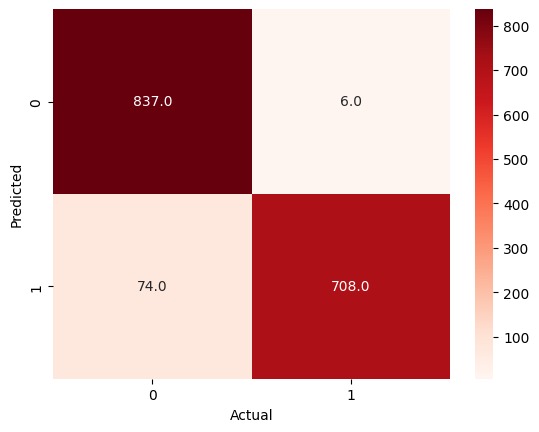

In [45]:
# Confusion matrix using heatmaps
sns.heatmap(
                data = confusion_matrix(y_test,y_pred),
                cmap = "Reds",
                annot=True,
                fmt='.1f'
)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [39]:
# For verification calculate the cross cal score 
from sklearn.model_selection import cross_val_score
cross_val_score(
                    nvb_categorical_clf,
                    X_train,
                    y_train,
                    cv = 10
).mean()*100

np.float64(95.35301647505037)